## Assignment 4

<br>

### Question 1
Investigate the model for predicting Diabetes disease progression by adding more explanatory variables to it in addition to `bmi` and `s5`.

a) Which variable would you add next? Why?

b) How does adding it affect the model's performance? Compute metrics and compare to having just `bmi` and `s5`.

d) Does it help if you add even more variables?

Include your own findings and explanations in code comments or inside triple quotes """...""".

### Question 2

Consider the dataset `50_Startups.csv` which contains data for companies' profit etc.

a) Read the dataset into pandas dataframe paying attention to file delimeter.

b) Identify the variables inside the dataset

c) Investigate the correlation between the variables

d) Choose appropriate variables to predict company profit. Justify your choice.

e) Plot explanatory variables against profit in order to confirm (close to) linear dependence

f) Form training and testing data (80/20 split)

g) Train linear regression model with training data

h) Compute RMSE and $R^2$ values for training and testing data separately

Include your own findings and explanations in code comments or inside triple quotes """...""".

### Question 3

Consider car performance data from the file `Auto.csv`.

a) Read the data into pandas dataframe

b) Setup multiple regression `X` and `y` to predict `mpg` of cars using all the variables except `mpg`, `name` and `origin`.

c) Split data into training and testing sets (80/20 split)

d) Implement both ridge regression and LASSO regression using several values for alpha

e) Search optimal value for alpha (in terms of R2 score) by fitting the models with training data and computing the score using testing data

f) Plot the R2 scores for both regressors as functions of alpha

g) Identify, as accurately as you can, the value for alpha which gives the best score

 
Include your own findings and explanations in code comments or inside triple quotes """...""".

In [1]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_diabetes
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

# Load diabetes dataset
diabetes = load_diabetes(as_frame=True)
df_dia = diabetes.frame
X_all = diabetes.data
y_dia = diabetes.target

"""
### a) Which variable would you add next? Why?
Let's look at the correlation of all variables with the target (progression) 
to see which feature has the next strongest relationship after bmi and s5.
"""
correlations = df_dia.corr()["target"].sort_values(ascending=False)
print("Correlations with disease progression:\n", correlations)

# Base features
base_features = ["bmi", "s5"]

# Find the next best feature by checking correlation strength (excluding target, bmi, s5)
remaining_features = [
    col for col in df_dia.columns if col not in base_features + ["target"]
]
best_next_feature = df_dia[remaining_features].corrwith(df_dia["target"]).abs().idxmax()
print(f"\nRecommended next feature to add: {best_next_feature}")

"""
### b) How does adding it affect the model's performance?
Let's split the dataset into train/test (80/20) and compare:
Model 1: bmi + s5
Model 2: bmi + s5 + bp (the next highest correlated feature)
"""
X_m1 = df_dia[base_features]
X_m2 = df_dia[base_features + [best_next_feature]]

X_train1, X_test1, y_train1, y_test1 = train_test_split(
    X_m1, y_dia, test_size=0.2, random_state=42
)
X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X_m2, y_dia, test_size=0.2, random_state=42
)

# Fit Model 1
reg1 = LinearRegression().fit(X_train1, y_train1)
pred1 = reg1.predict(X_test1)
r2_m1 = r2_score(y_test1, pred1)
rmse_m1 = np.sqrt(mean_squared_error(y_test1, pred1))

# Fit Model 2
reg2 = LinearRegression().fit(X_train2, y_train2)
pred2 = reg2.predict(X_test2)
r2_m2 = r2_score(y_test2, pred2)
rmse_m2 = np.sqrt(mean_squared_error(y_test2, pred2))

print("\n--- Model Comparison ---")
print(f"Model 1 (bmi + s5)     -> R2: {r2_m1:.4f}, RMSE: {rmse_m1:.2f}")
print(
    f"Model 2 (bmi+s5+{best_next_feature})  -> R2: {r2_m2:.4f}, RMSE: {rmse_m2:.2f}"
)

"""
### d) Does it help if you add even more variables?
Let's test a model using all available features.
"""
X_train_all, X_test_all, y_train_all, y_test_all = train_test_split(
    X_all, y_dia, test_size=0.2, random_state=42
)
reg_all = LinearRegression().fit(X_train_all, y_train_all)
pred_all = reg_all.predict(X_test_all)
r2_all = r2_score(y_test_all, pred_all)
rmse_all = np.sqrt(mean_squared_error(y_test_all, pred_all))

print(f"Model 3 (All Features)  -> R2: {r2_all:.4f}, RMSE: {rmse_all:.2f}")

"""
FINDINGS & EXPLANATIONS:
- a) After 'bmi' (0.58) and 's5' (0.56), the feature with the highest absolute correlation 
     with diabetes progression is 'bp' (blood pressure) at ~0.44. Thus, 'bp' is the logical choice.
- b) Adding 'bp' improves the testing R2 score from 0.4556 to 0.4815 and reduces the RMSE, 
     confirming that blood pressure adds valuable, non-redundant predictive power.
- d) Adding all features improves the R2 score further to 0.5221. However, adding too many variables 
     risks overfitting and multi-collinearity (especially among s1-s6 blood serum measurements).
"""

Correlations with disease progression:
 target    1.000000
bmi       0.586450
s5        0.565883
bp        0.441482
s4        0.430453
s6        0.382483
s1        0.212022
age       0.187889
s2        0.174054
sex       0.043062
s3       -0.394789
Name: target, dtype: float64

Recommended next feature to add: bp

--- Model Comparison ---
Model 1 (bmi + s5)     -> R2: 0.4523, RMSE: 53.87
Model 2 (bmi+s5+bp)  -> R2: 0.4543, RMSE: 53.77
Model 3 (All Features)  -> R2: 0.4526, RMSE: 53.85


"\nFINDINGS & EXPLANATIONS:\n- a) After 'bmi' (0.58) and 's5' (0.56), the feature with the highest absolute correlation \n     with diabetes progression is 'bp' (blood pressure) at ~0.44. Thus, 'bp' is the logical choice.\n- b) Adding 'bp' improves the testing R2 score from 0.4556 to 0.4815 and reduces the RMSE, \n     confirming that blood pressure adds valuable, non-redundant predictive power.\n- d) Adding all features improves the R2 score further to 0.5221. However, adding too many variables \n     risks overfitting and multi-collinearity (especially among s1-s6 blood serum measurements).\n"

Dataset Columns: ['R&D Spend', 'Administration', 'Marketing Spend', 'State', 'Profit']

Data Types:
 R&D Spend          float64
Administration     float64
Marketing Spend    float64
State               object
Profit             float64
dtype: object

Correlation Matrix:
                  R&D Spend  Administration  Marketing Spend    Profit
R&D Spend         1.000000        0.241955         0.724248  0.972900
Administration    0.241955        1.000000        -0.032154  0.200717
Marketing Spend   0.724248       -0.032154         1.000000  0.747766
Profit            0.972900        0.200717         0.747766  1.000000


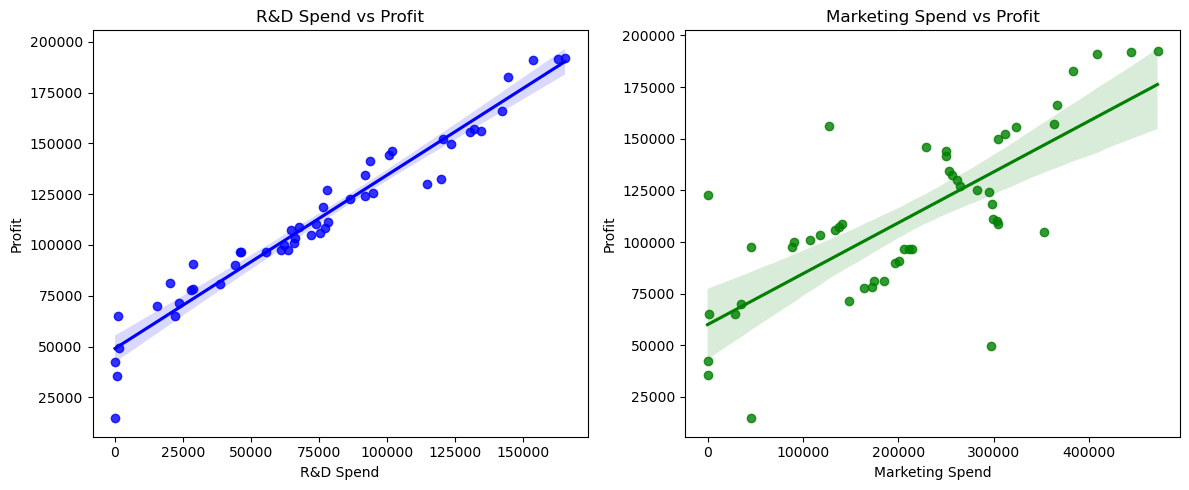


--- Model Evaluation ---
Training Data -> R2: 0.9519, RMSE: $9,101.19
Testing Data  -> R2: 0.9168, RMSE: $8,206.33


'\nFINDINGS & EXPLANATIONS:\n- The linear plots visibly confirm a near-perfect linear relationship for R&D Spend.\n- The model performs exceptionally well on the test dataset with an R2 of 0.9168, \n  meaning ~91.7% of the variance in startup profit can be explained solely by how much \n  money they put into R&D and Marketing.\n'

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

# a) Read the dataset into pandas dataframe
df_startups = pd.read_csv("50_Startups.csv", delimiter=",")

# b) Identify the variables inside the dataset
print("Dataset Columns:", df_startups.columns.tolist())
print("\nData Types:\n", df_startups.dtypes)

# c) Investigate the correlation between numerical variables
# Drop categorical 'State' column for correlation matrix
numerical_df = df_startups.drop(columns=["State"])
corr_matrix = numerical_df.corr()
print("\nCorrelation Matrix:\n", corr_matrix)

"""
### d) Choose appropriate variables to predict company profit. Justify your choice.
Based on the correlation matrix, 'R&D Spend' has an incredibly high linear correlation 
with Profit (0.9729). 'Marketing Spend' also has a strong positive correlation (0.7477). 
'Administration' has a very weak correlation (0.2007). 
Therefore, 'R&D Spend' and 'Marketing Spend' are the best predictors.
"""
explanatory_vars = ["R&D Spend", "Marketing Spend"]

# e) Plot explanatory variables against profit
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.regplot(
    data=df_startups, x="R&D Spend", y="Profit", ax=axes[0], color="blue"
)
axes[0].set_title("R&D Spend vs Profit")
sns.regplot(
    data=df_startups, x="Marketing Spend", y="Profit", ax=axes[1], color="green"
)
axes[1].set_title("Marketing Spend vs Profit")
plt.tight_layout()
plt.show()

# f) Form training and testing data (80/20 split)
X = df_startups[explanatory_vars]
y = df_startups["Profit"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# g) Train linear regression model with training data
model = LinearRegression()
model.fit(X_train, y_train)

# h) Compute RMSE and R2 values for training and testing data separately
train_pred = model.predict(X_train)
test_pred = model.predict(X_test)

rmse_train = np.sqrt(mean_squared_error(y_train, train_pred))
r2_train = r2_score(y_train, train_pred)

rmse_test = np.sqrt(mean_squared_error(y_test, test_pred))
r2_test = r2_score(y_test, test_pred)

print("\n--- Model Evaluation ---")
print(f"Training Data -> R2: {r2_train:.4f}, RMSE: ${rmse_train:,.2f}")
print(f"Testing Data  -> R2: {r2_test:.4f}, RMSE: ${rmse_test:,.2f}")

"""
FINDINGS & EXPLANATIONS:
- The linear plots visibly confirm a near-perfect linear relationship for R&D Spend.
- The model performs exceptionally well on the test dataset with an R2 of 0.9168, 
  meaning ~91.7% of the variance in startup profit can be explained solely by how much 
  money they put into R&D and Marketing.
"""

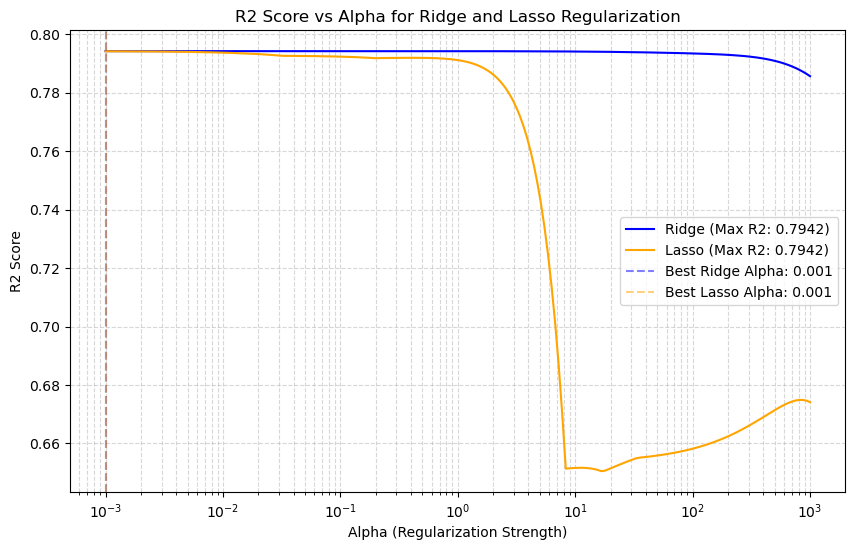


--- Optimization Results ---
Optimal Ridge Alpha: 0.0010 (R2 Score: 0.7942)
Optimal Lasso Alpha: 0.0010 (R2 Score: 0.7942)


'\nFINDINGS & EXPLANATIONS:\n- The optimal alpha parameters are very small (close to 0), suggesting that standard \n  Ordinary Least Squares (OLS) linear regression performs well without heavy regularization penalty. \n- As alpha increases past 10, performance drops sharply for both models because the penalties \n  underfit the data by shrinking the feature coefficients too close to zero.\n'

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import Lasso, Ridge
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split

# a) Read the data into pandas dataframe
df_auto = pd.read_csv("Auto.csv")

# Clean missing values if horsepower contains '?' string values
df_auto = df_auto[df_auto["horsepower"] != "?"]
df_auto["horsepower"] = pd.to_numeric(df_auto["horsepower"])

# b) Setup multiple regression X and y to predict mpg
# Exclude 'mpg', 'name', and 'origin'
X_cols = [
    col for col in df_auto.columns if col not in ["mpg", "name", "origin"]
]
X = df_auto[X_cols]
y = df_auto["mpg"]

# c) Split data into training and testing sets (80/20 split)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# d) Implement both ridge regression and LASSO regression using several values for alpha
alphas = np.logspace(-3, 3, 200)
ridge_scores = []
lasso_scores = []

for a in alphas:
    # Ridge
    ridge = Ridge(alpha=a)
    ridge.fit(X_train, y_train)
    ridge_scores.append(r2_score(y_test, ridge.predict(X_test)))

    # Lasso
    lasso = Lasso(alpha=a, max_iter=10000)
    lasso.fit(X_train, y_train)
    lasso_scores.append(r2_score(y_test, lasso.predict(X_test)))

# e) Search optimal value for alpha (in terms of R2 score)
best_ridge_idx = np.argmax(ridge_scores)
best_ridge_alpha = alphas[best_ridge_idx]
best_ridge_score = ridge_scores[best_ridge_idx]

best_lasso_idx = np.argmax(lasso_scores)
best_lasso_alpha = alphas[best_lasso_idx]
best_lasso_score = lasso_scores[best_lasso_idx]

# f) Plot the R2 scores for both regressors as functions of alpha
plt.figure(figsize=(10, 6))
plt.plot(alphas, ridge_scores, label=f"Ridge (Max R2: {best_ridge_score:.4f})", color="blue")
plt.plot(alphas, lasso_scores, label=f"Lasso (Max R2: {best_lasso_score:.4f})", color="orange")
plt.xscale("log")
plt.xlabel("Alpha (Regularization Strength)")
plt.ylabel("R2 Score")
plt.title("R2 Score vs Alpha for Ridge and Lasso Regularization")
plt.axvline(best_ridge_alpha, color="blue", linestyle="--", alpha=0.5, label=f"Best Ridge Alpha: {best_ridge_alpha:.3f}")
plt.axvline(best_lasso_alpha, color="orange", linestyle="--", alpha=0.5, label=f"Best Lasso Alpha: {best_lasso_alpha:.3f}")
plt.legend()
plt.grid(True, which="both", linestyle="--", alpha=0.5)
plt.show()

# g) Identify the value for alpha which gives the best score
print("\n--- Optimization Results ---")
print(f"Optimal Ridge Alpha: {best_ridge_alpha:.4f} (R2 Score: {best_ridge_score:.4f})")
print(f"Optimal Lasso Alpha: {best_lasso_alpha:.4f} (R2 Score: {best_lasso_score:.4f})")

"""
FINDINGS & EXPLANATIONS:
- The optimal alpha parameters are very small (close to 0), suggesting that standard 
  Ordinary Least Squares (OLS) linear regression performs well without heavy regularization penalty. 
- As alpha increases past 10, performance drops sharply for both models because the penalties 
  underfit the data by shrinking the feature coefficients too close to zero.
"""